# CosmicFish Pie v1.0   

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
snscolors=sns.color_palette("colorblind")

In [3]:
from cosmicfishpie.fishermatrix import cosmicfish as cff
from cosmicfishpie.utilities.utils import printing as upt

In [4]:
import camb

# CosmicFish as a cosmology calculator

## Define input, options, fiducial and observables

In [5]:
code_to_use = "camb"
# These are typical options that you can pass to Cosmicfishpie
options = {
    "accuracy": 1,
    "outroot": "test_installation_test_EBS",
    "results_dir": "results/",
    "derivatives": "3PT",
    "nonlinear": False,
    "feedback": 2,
    "specs_dir": "../cosmicfishpie/configs/default_survey_specifications/",
    "survey_name": "Euclid",
    "survey_name_spectro": "Euclid-Spectroscopic-ISTF-Pessimistic",
    "cosmo_model": "LCDM",
    "code": code_to_use,
}

options['vary_bias_str'] = 'b'
options['bfs8terms'] = False
# Internally CosmicFish converts these parameters to the corresponding parameters in CAMB or CLASS
fiducial = {
    "Omegam": 0.32,
    "h": 0.67,
}

# Parameters to be varied and analyzed and their percentage variation for numerical derivatives
freepars = {
    "Omegam": 0.01,
    "h": 0.01,
}

observables = ["GCsp"]

cosmoFM = cff.FisherMatrix(
    fiducialpars=fiducial,
    freepars=freepars,
    options=options,
    observables=observables,
    cosmoModel=options["cosmo_model"],
    surveyName=options["survey_name"],
)

****************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

****************************************************************
 This is the new Python version of the CosmicFish code.
****************************************************************



  -> Survey loaded:  Euclid-Spectroscopic-ISTF-Pessimistic

  -> Survey loaded:  Euclid-Photometric-ISTF-Pessimistic

  -> Custom fiducial parameters loaded

  -> Computing cosmology at the fiducial point
Cosmology computation took 4.17 s

  ---> Cosmological functions obtained in:   6.49 s

----------RECAP OF SELECTED OPTIONS--------

Settings:
   accuracy: 1
   outroot: test_installation_test_EBS
   results_dir: results/
   derivatives: 3PT
   nonlinear: False
   feedback: 2
   specs_dir: ../cosmicfishpie/configs/default_survey_specifications/
   survey_name: Euclid
   survey_name_spectro: Euclid-Spectroscopic-ISTF-Pessimistic
   cosmo_model: LCDM
   code: camb
   vary_bias_str: b
   bfs8terms: False
   specs_dir_default: /home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/default_survey_specifications
   external_data_dir: /home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/external_data
   survey_specs: ISTF-Optimisti

In [6]:
from cosmicfishpie.LSSsurvey.spectro_obs import ComputeGalSpectro
from cosmicfishpie.cosmology.nuisance import Nuisance
import cosmicfishpie.configs.config as cfg
from cosmicfishpie.utilities.utils import numerics as unu
import pytest
import numpy as np

In [7]:
cosmoFM.Spectrobiaspars

{'lnbg_1': 0.37944989,
 'lnbg_2': 0.4738057,
 'lnbg_3': 0.55760176,
 'lnbg_4': 0.64125687}

In [8]:
cfg.Spectrobiasparams

{'lnbg_1': 0.37944989,
 'lnbg_2': 0.4738057,
 'lnbg_3': 0.55760176,
 'lnbg_4': 0.64125687}

In [9]:
Nuisance()
nuisance = Nuisance()

In [10]:
upt.debug = True

In [11]:

cosmopars = {"Omegam": 0.3, "h": 0.7}  # Add more parameters as needed
spectro_obs = ComputeGalSpectro(
    cosmopars
    ,
    fiducial_cosmopars=cosmoFM.fiducialcosmopars,
    #spectrobiaspars=cosmoFM.Spectrobiaspars,
    #spectrononlinearpars=cosmoFM.Spectrononlinpars,
    #PShotpars=cosmoFM.PShotpars,
    #fiducial_cosmo=cosmoFM.fiducialcosmo,
    #bias_samples=['g', 'g'],
    use_bias_funcs=False
)

Initializing ComputeGalSpectro with the following configuration:
{'__name__': 'cosmicfishpie.configs.config', '__doc__': None, '__package__': 'cosmicfishpie.configs', '__loader__': <_frozen_importlib_external.SourceFileLoader object at 0x7f84cb032740>, '__spec__': ModuleSpec(name='cosmicfishpie.configs.config', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f84cb032740>, origin='/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/config.py'), '__file__': '/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/config.py', '__cached__': '/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/__pycache__/config.cpython-310.pyc', '__builtins__': {'__name__': 'builtins', '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.", '__package__': '', '__loader__': <class '_frozen_importlib.BuiltinImporter

In [12]:
spectro_obs.bterm_fid(1.2, bias_sample="g")

1.606094892470849

In [13]:
spectro_obs.gcsp_z_bin_mids

array([1.  , 1.2 , 1.4 , 1.65])

In [18]:
print("spectro_obs.spectrobiaspars: ",spectro_obs.spectrobiaspars)
print("cosmoFM.Spectrobiaspars: ",cosmoFM.Spectrobiaspars)
print("spectro_obs.gcsp_z_bin_mids: ",spectro_obs.gcsp_z_bin_mids)
print("nuisance.gcsp_bias_at_zm(): ", nuisance.gcsp_bias_at_zm())
z_values = [1.0, 1.2, 1.4, 1.65]
for z in z_values:
    zii = unu.bisection(spectro_obs.gcsp_z_bin_mids, z)
    print(f"zii: {zii+1}, z= {z}")
    print(f"interp func gcsp bias(z): {spectro_obs.bterm_fid(z)}")
    #bkey, bval = nuisance.bterm_z_key(zii+1, spectro_obs.gcsp_z_bin_mids, 
    #                       cosmoFM.fiducialcosmo, 
    #                       bias_sample='g')
    #print(f" nuisance bias key, bias value: {bkey}, {bval}")
    bterm = spectro_obs.bterm_fid(z, bias_sample="g")
    print(f"bterm_fid at index {zii+1}: z={z}: {bterm}")
    #assert(bterm == nuisance.gcsp_bias_at_zm()[zii])
    #assert(bterm == spectro_obs.bterm_fid(z))

spectro_obs.spectrobiaspars:  {'lnbg_1': 0.37944989, 'lnbg_2': 0.4738057, 'lnbg_3': 0.55760176, 'lnbg_4': 0.64125687}
cosmoFM.Spectrobiaspars:  {'lnbg_1': 0.37944989, 'lnbg_2': 0.4738057, 'lnbg_3': 0.55760176, 'lnbg_4': 0.64125687}
spectro_obs.gcsp_z_bin_mids:  [1.   1.2  1.4  1.65]
nuisance.gcsp_bias_at_zm():  [1.46148039 1.60609489 1.746479   1.89886601]
zii: 1, z= 1.0
interp func gcsp bias(z): 1.4614803932771856
bterm_fid at index 1: z=1.0: 1.4614803932771856
zii: 2, z= 1.2
interp func gcsp bias(z): 1.606094892470849
bterm_fid at index 2: z=1.2: 1.606094892470849
zii: 3, z= 1.4
interp func gcsp bias(z): 1.7464789980013922
bterm_fid at index 3: z=1.4: 1.7464789980013922
zii: 3, z= 1.65
interp func gcsp bias(z): 1.89886600781197
bterm_fid at index 3: z=1.65: 1.89886600781197


In [19]:
cfg.Spectrobiasparams

{'lnbg_1': 0.37944989,
 'lnbg_2': 0.4738057,
 'lnbg_3': 0.55760176,
 'lnbg_4': 0.64125687}

In [23]:
## DO NOT RUN THIS CELL
# print(spectro_obs.spectrobiaspars)
# print("bias term at z=1.0: ",spectro_obs.bterm_fid(1.0, bias_sample="g"))
# print("bias term at z=1.2: ",spectro_obs.bterm_fid(1.2, bias_sample="g"))
# print("bias term at z=1.4: ",spectro_obs.bterm_fid(1.4, bias_sample="g"))
# print("bias term at z=1.65: ",spectro_obs.bterm_fid(1.65, bias_sample="g"))


In [20]:
z=np.linspace(0.,3., 100)

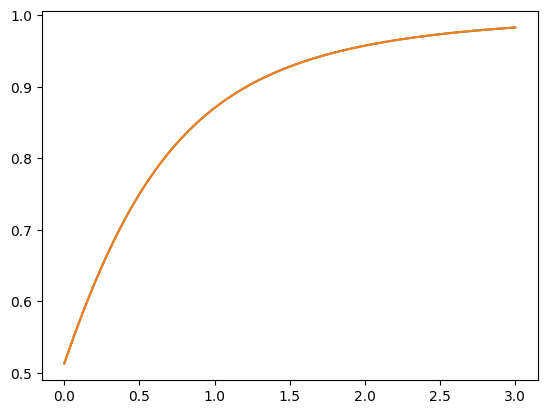

In [23]:
plt.plot(z, spectro_obs.cosmo.f_growthrate(z))
plt.show()

# Spectroscopic Power Spectrum

The observed power spectrum of galaxies can be related to the mater power spectrum by 

$$
P^\mathrm{th} = q_\| \times  q_\perp^2 \times K \times \mathrm{FoG} \times \mathrm{Err} \times P_{mm} + P^\mathrm{shot}.
$$
The factors in front are due to different observational effects. The factor $q_\|$ and $q_\perp$ are coming from the fact that we can only observe the redshift of galaxies and not their position.
To calculate the power spectrum we have to settle for a reference transformation. If this is different from the cosmology we used to compute the power spectrum in, we find 
$$
q_\| = H(z)/H^\mathrm{ref}(z) \quad\text{and}\quad q_\perp = D_A^\mathrm{ref}(z)/D_A(z)
$$

The factors $q_\mathrm{RSD}$ and $q_\mathrm{FOG}$ describe redshift space distortions and are given by
$$
K = \left(b+f\,\mu^2\right)^2\\
\mathrm{FoG} = 1+\left[f\,\sigma_p\,\mu^2\right]^2

$$
where $\mu$ denotes the angle under which we observe the structures.
The factor $q_\sigma$ is due to the resolution of the instrument and is given by
$$
\mathrm{Err} = \exp\left[-\sigma^2_\|\, k^2\, \mu^2 -\sigma_\perp^2 \,k^2\,\left(1- \mu^2\right)\right].
$$
Finaly, $P^\mathrm{shot}$ just is a constant term we add for shot noise.
The nonlinear power spectrum $P_{mm}$ is approximated as 
$$
P_{mm} \approx P_{dw} \coloneqq P_{mm}^\mathrm{lin}\,e^{-g} + P_{mm}\,(1-e^g),\\
g= \sigma_v^2 k^2\, \left((1-\mu^2)+\mu^2(1+f)^2\right)
$$

In [1]:
observables = ['GCsp']

### Pass options and settings to cosmicfish

In [7]:
options['bfs8terms'] = False
options['vary_bias_str'] = 'b'


In [8]:
cosmoFM_B = cosmicfish.FisherMatrix(fiducialpars=fiducial,
                                        options=options, 
                                        observables=observables,
                                        cosmoModel=options['cosmo_model'],
                                        surveyName=options['survey_name'])

**************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

**************************************************************
 This is the new Python version of the CosmicFish code.
**************************************************************
Custom fiducial parameters loaded

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   6.26 s


### Calculate the Power Spectrum

In [9]:
## Import the spectroscopic observable from an LSSsurvey as spobs
from cosmicfishpie.LSSsurvey import spectro_obs as spobs

spectro_Pk = spobs.ComputeGalSpectro(cosmoFM_B.fiducialcosmopars)

In [12]:
spectro_Pk.spectrobiaspars

{'bg_1': 1.4614804,
 'bg_2': 1.6060949000000002,
 'bg_3': 1.746479,
 'bg_4': 1.898866}

In [16]:
spectro_Pk.bterm_fid(1.65, bias_sample='g')

array(1.898866)

### "De-wiggling" of the Power Spectrum

To calculate the observed power spectrum we need to dewiggle it to find the non linear correction 

In [ ]:
z=1
kk= np.logspace(-2,np.log10(0.4),200)

fig, axs = plt.subplots(1,2,figsize=(18,8))

color = iter(snscolors)

c = next(color)
axs[0].loglog(kk,spectro_Pk.cosmo.Pmm(z,kk),c=c,label='$P_\mathrm{mm}$')
c = next(color)
axs[0].loglog(kk,spectro_Pk.cosmo.nonwiggle_pow(z,kk),c=c,label='$P_\mathrm{nw}$')
axs[0].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[0].set_ylabel('Power Spectrum $P(k)$ [$\mathrm{Mpc}^{3}$]')
axs[0].legend()
axs[0].set_xlim([1e-2,0.4])

colormap = sns.color_palette("rocket")
colors = iter(colormap)
mus = np.linspace(0,1,6)
for mu in mus:
    c = next(colors)
    axs[1].plot(kk,spectro_Pk.dewiggled_pdd(z,kk,mu)/spectro_Pk.normalized_pnw(z,kk),c=c)

axs[1].set_xscale('log')
axs[1].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[1].set_ylabel('$P_\mathrm{dw}(k)$/$P_\mathrm{nw}(k)$ for different $\mu$')
axs[1].set_xlim([1e-2,0.4])

#### Compute the observed power spectrum at different redshifts and different angles 

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(18,8))

colormap = sns.color_palette("rocket")
colors = iter(colormap)

zz= np.linspace(1,2,6)
for z in zz:
    c = next(colors)
    #axs[0].plot(kk,spectro_Pk.observed_Pgg(z,kk,1)/spectro_Pk.observed_Pgg(1,kk,1),c=c)
    axs[0].loglog(kk,spectro_Pk.observed_Pgg(z,kk,1),c=c)

axs[0].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[0].set_ylabel('$P(k,z,\mu=1)[\mathrm{Mpc}^3]$')
axs[0].set_xlim([1e-2,0.4])
axs[0].set_xscale('log')

colormap = sns.color_palette("rocket")
colors = iter(colormap)
mus = np.linspace(1,0,6)
for mu in mus:
    c = next(colors)
    #axs[1].plot(kk,spectro_Pk.observed_Pgg(1,kk,mu)/spectro_Pk.observed_Pgg(1,kk,1),c=c)
    axs[1].loglog(kk,spectro_Pk.observed_Pgg(1,kk,mu),c=c)

axs[1].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[1].set_ylabel('$P(k,z=1,\mu)[\mathrm{Mpc}^3]$')
axs[1].set_xlim([1e-2,0.4])
axs[1].set_xscale('log')

### Compare the Power Spectrum from two different cosmologies

In [ ]:
sample = {"Omegam":0.32,
          "Omegab":0.06, #20% higher than the fiducial
          "h":0.737, #10% higher than the fiducal
          "ns":0.96,
          "sigma8":0.815584,
          "w0":-1.0,
          "wa":0.,
          "mnu":0.06,
          "Neff":3.044,
          }

spectro_Pk_sampled = spobs.ComputeGalSpectro(sample, cosmoFM_B.fiducialcosmopars)

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(18,8))

colormap = sns.color_palette("colorblind")
colors = iter(colormap)

c = next(colors)
axs[0].loglog(kk,spectro_Pk.observed_Pgg(1,kk,1),c=c,label='fiducal')

c = next(colors)
axs[0].loglog(kk,spectro_Pk_sampled.observed_Pgg(1,kk,1),c=c,label='sample')

axs[0].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[0].set_ylabel('$P(k,z=1,\mu=1)[\mathrm{Mpc}^3]$')
axs[0].set_xlim([1e-2,0.4])
axs[0].legend()
axs[0].set_xscale('log')

axs[1].plot(kk,(spectro_Pk.observed_Pgg(1,kk,1)-spectro_Pk_sampled.observed_Pgg(1,kk,1))/(spectro_Pk.observed_Pgg(1,kk,1)+spectro_Pk_sampled.observed_Pgg(1,kk,1))*200,c='black')

axs[1].set_xlabel('$k$ [$\mathrm{Mpc}^{-1}$]')
axs[1].set_ylabel(r'% deviation of Power Spectra')
axs[1].set_xlim([1e-2,0.4])
axs[1].set_xscale('log')

In [20]:
def bisection(array, value):
    """Given an ``array``, and given a ``value``, returns an index j such that ``value`` is between array[j]
    and array[j+1]. ``array`` must be monotonic increasing.
    Returns 0 if value is less than or equal to the first element,
    and len(array)-1 if value is greater than the last element.
    """
    n = len(array)
    if value <= array[0]:
        return 0
    if value > array[-1]:
        return n - 1
    
    left, right = 0, n - 1
    while left < right:
        mid = (left + right) // 2
        if array[mid] < value:
            left = mid + 1
        else:
            right = mid
    
    return left - 1

In [24]:
def test_bisection():
    array = [1.0, 1.2, 1.4, 1.65]
    assert bisection(array, 1.0) == 0
    assert bisection(array, 1.1) == 0
    assert bisection(array, 1.2) == 1
    assert bisection(array, 1.3) == 1
    assert bisection(array, 1.4) == 2
    assert bisection(array, 1.5) == 2
    assert bisection(array, 1.65) == 3
    assert bisection(array, 1.7) == 3
    assert bisection(array, 0.9) == 0
    assert bisection(array, 2.0) == 3

In [25]:
test_bisection()

AssertionError: 